# **Setup et structure**

# **Imports et vérification**

In [ ]:
import os, glob, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import soundfile as sf
from IPython.display import Audio, display

warnings.filterwarnings("ignore")

# add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from config import (
    BASE_DIR,
    SPLIT_FILE,
    RES_DIR,
    TARGET_SR,
    TARGET_SEC,
    TARGET_LEN,
    N_MELS,
    N_FFT,
    HOP_LENGTH,
    FMIN,
    FMAX,
    NUM_CLASSES,
    RARE_CLASSES,
    USE_MIXUP,
    USE_SPECAUGMENT,
    P_PITCH,
    P_MIXUP,
    LABEL_NAMES,
)

# dataset check
wav_files = glob.glob(f"{config.DATA_DIR}/*.wav")
txt_files = glob.glob(f"{config.DATA_DIR}/*.txt")

print(f"WAV : {len(wav_files)} fichiers")
print(f"TXT : {len(txt_files)} fichiers")

sample_txt = txt_files[0]
df_sample = pd.read_csv(sample_txt, sep="\t", names=["start", "end", "crackle", "wheeze"])

print("\nExemple annotation :")
print(df_sample.head())

WAV : 920 fichiers
TXT : 922 fichiers

Exemple annotation :
     start     end  crackle  wheeze
0    0.092   1.685        0       0
1    1.685   3.311        0       0
2    3.311   4.904        0       0
3    4.904   6.496        0       0
4    6.496   8.055        0       0
5    8.055   9.631        0       0
6    9.631  11.056        0       0
7   11.056  12.548        0       0
8   12.548  14.007        0       0
9   14.007  15.566        0       0
10  15.566  17.058        0       0
11  17.058  18.701        0       0
12  18.701  19.573        0       0


## **DataFrame global**

In [ ]:
LABEL_MAP = {(0,0):0, (1,0):1, (0,1):2, (1,1):3}
LABEL_NAMES = ['Normal', 'Crackle', 'Wheeze', 'Both']
records = []
for wav_path in wav_files:
    fname = os.path.splitext(os.path.basename(wav_path))[0]
    txt_path = wav_path.replace('.wav', '.txt')
    if not os.path.exists(txt_path):
        continue
    parts = fname.split('_')
    patient_id = parts[0]
    device = parts[-1]
    # Durée audio
    info = sf.info(wav_path)
    duration = info.duration
    sr_orig = info.samplerate
    anns = pd.read_csv(txt_path, sep='\t', names=['start','end','crackle','wheeze'])
    for _, row in anns.iterrows():
        label = LABEL_MAP[(int(row.crackle), int(row.wheeze))]
        records.append({
            'filename' : fname,
            'wav_path' : wav_path,
            'patient_id': patient_id,
            'device' : device,
            'start' : row.start,
            'end' : row.end,
            'cycle_dur' : row.end - row.start,
            'crackle' : int(row.crackle),
            'wheeze' : int(row.wheeze),
            'label' : label,
            'label_name': LABEL_NAMES[label],
            'file_dur' : duration,
            'sr_orig' : sr_orig,
        })

df = pd.DataFrame(records)
print(f"Total cycles : {len(df)}") # attendu : ~6898
print(df['label_name'].value_counts())
df.to_csv(f"{config.BASE_DIR}/results/metadata.csv", index=False)
df.head()

Total cycles : 6898
label_name
Normal     3642
Crackle    1864
Wheeze      886
Both        506
Name: count, dtype: int64


,filename,wav_path,patient_id,device,start,end,cycle_dur,crackle,wheeze,label,label_name,file_dur,sr_orig
0,101_1b1_Al_sc_Meditron,/content/drive/MyDrive/ICBHI_Project/ICBHI_fin...,101,Meditron,0.036,0.579,0.543,0,0,0,Normal,20.0,44100
1,101_1b1_Al_sc_Meditron,/content/drive/MyDrive/ICBHI_Project/ICBHI_fin...,101,Meditron,0.579,2.450,1.871,0,0,0,Normal,20.0,44100
2,101_1b1_Al_sc_Meditron,/content/drive/MyDrive/ICBHI_Project/ICBHI_fin...,101,Meditron,2.450,3.893,1.443,0,0,0,Normal,20.0,44100
3,101_1b1_Al_sc_Meditron,/content/drive/MyDrive/ICBHI_Project/ICBHI_fin...,101,Meditron,3.893,5.793,1.900,0,0,0,Normal,20.0,44100
4,101_1b1_Al_sc_Meditron,/content/drive/MyDrive/ICBHI_Project/ICBHI_fin...,101,Meditron,5.793,7.521,1.728,0,0,0,Normal,20.0,44100


# **Visualisations**

## **Distribution des classes**

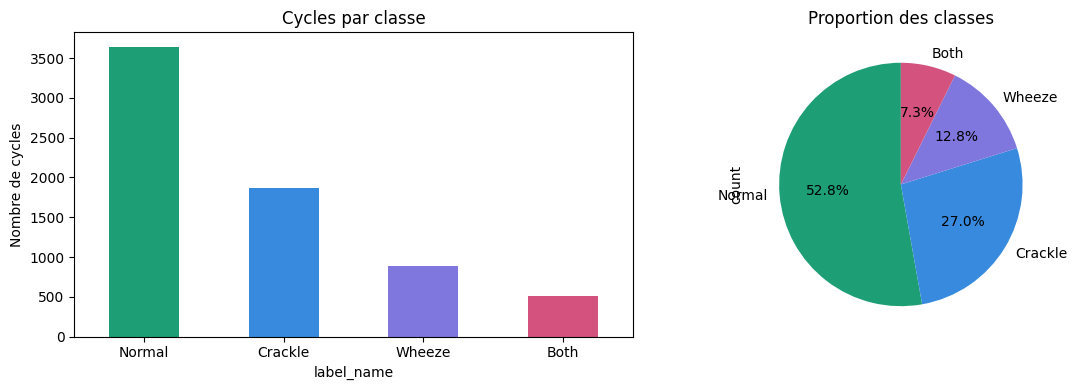

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
# Comptage
counts = df['label_name'].value_counts()
colors = ['#1D9E75','#378ADD','#7F77DD','#D4537E']
counts.plot.bar(ax=axes[0], color=colors, rot=0)
axes[0].set_title('Cycles par classe')
axes[0].set_ylabel('Nombre de cycles')
# Pie
counts.plot.pie(ax=axes[1], colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion des classes')
plt.tight_layout()
plt.savefig(f"{config.BASE_DIR}/figures/class_dist.png")
plt.show()

## **Durée des cycles par classe**

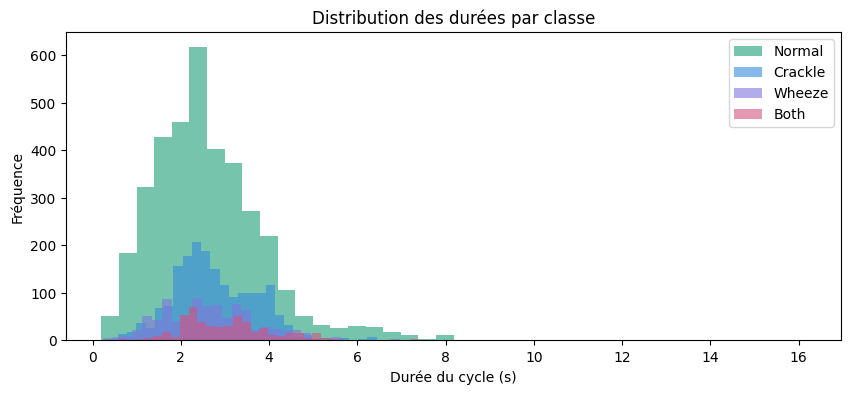

             count  mean   std   min   25%   50%   75%    max
label_name                                                   
Both         506.0  3.06  1.09  0.57  2.24  2.90  3.56   8.59
Crackle     1864.0  2.78  0.95  0.37  2.14  2.63  3.45   8.74
Normal      3642.0  2.61  1.28  0.20  1.72  2.44  3.29  16.16
Wheeze       886.0  2.70  1.14  0.23  1.80  2.58  3.36   9.22


In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
for i, name in enumerate(LABEL_NAMES):
  subset = df[df.label_name==name]['cycle_dur']
  ax.hist(subset, bins=40, alpha=0.6, label=name, color=colors[i])
  ax.set_xlabel('Durée du cycle (s)')
  ax.set_ylabel('Fréquence')
  ax.set_title('Distribution des durées par classe')
  ax.legend()
  plt.savefig(f"{config.BASE_DIR}/figures/cycle_durations.png")
plt.show()
print(df.groupby('label_name')['cycle_dur'] .describe().round(2))

## **Écouter un cycle de chaque classe**



── Normal ──


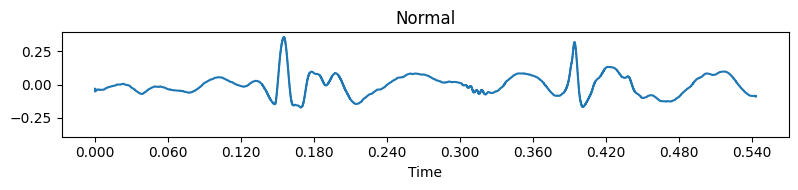


── Crackle ──


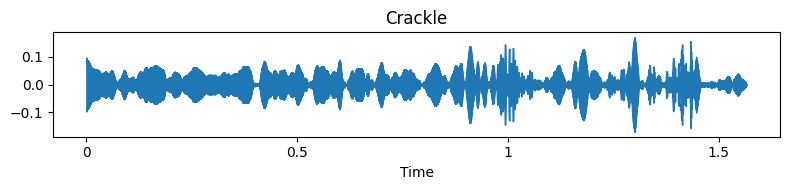


── Wheeze ──


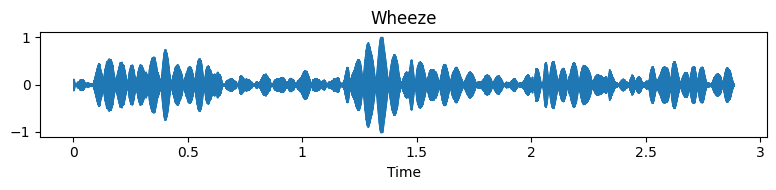


── Both ──


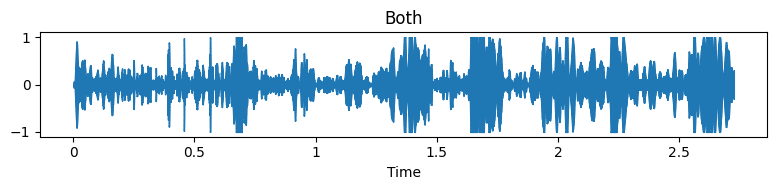

In [45]:
SR = 16000
for label_id in range(4):
  row = df[df.label==label_id].iloc[0]
  audio, _ = librosa.load(row.wav_path, sr=SR, offset=row.start, duration=row.cycle_dur)
  print(f"\n── {row.label_name} ──")
  display(Audio(audio, rate=SR))
  # widget player
  fig, ax = plt.subplots(figsize=(8,2))
  librosa.display.waveshow(audio, sr=SR, ax=ax)
  ax.set_title(row.label_name)
  plt.tight_layout();
  plt.show()

# **Spectrogrammes comparés**

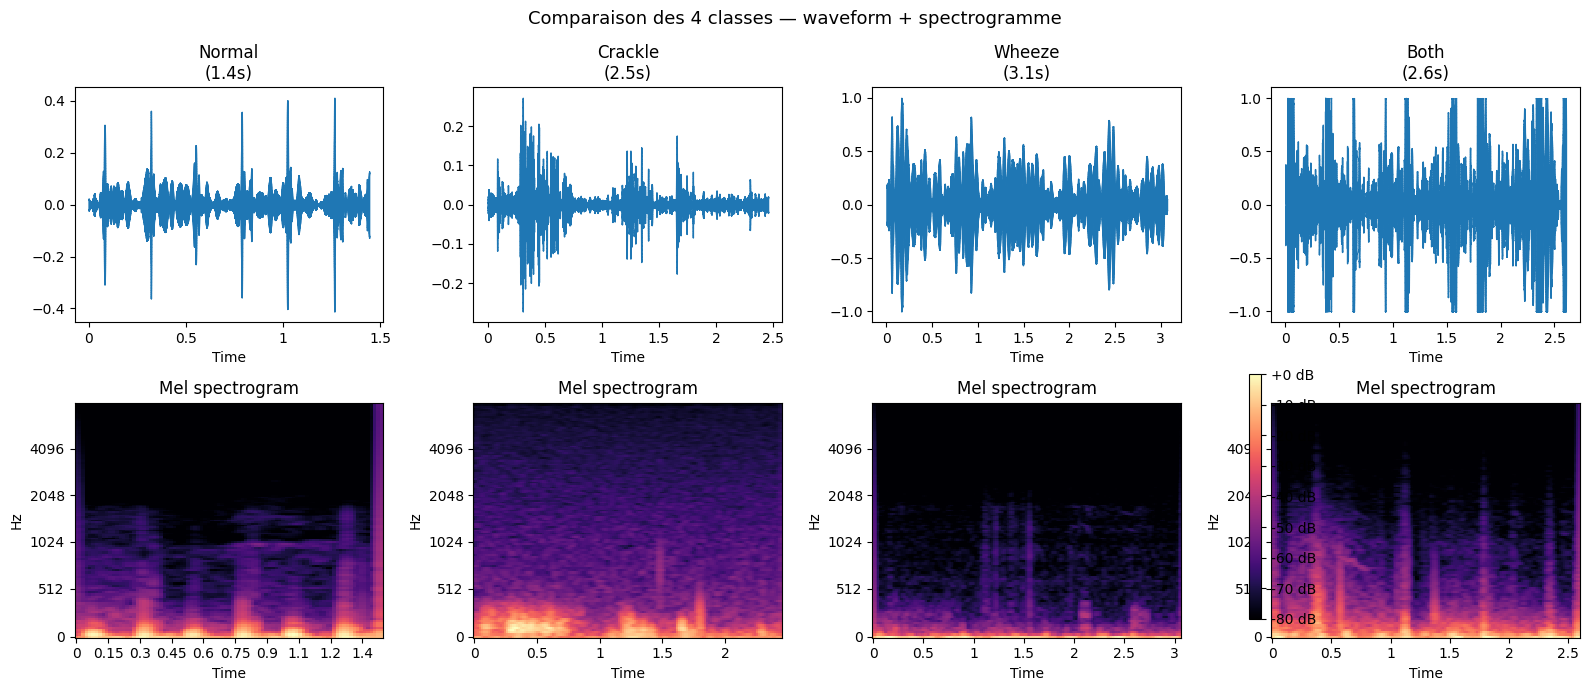

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
SR = 16000
N_MELS = 128
HOP = 256

for label_id in range(4):
    row = df[df.label == label_id].iloc[2]
    audio, _ = librosa.load(row.wav_path, sr=SR, offset=row.start, duration=row.cycle_dur)

    librosa.display.waveshow(audio, sr=SR, ax=axes[0][label_id])
    axes[0][label_id].set_title(f"{LABEL_NAMES[label_id]}\n({len(audio)/SR:.1f}s)")

    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_mels=N_MELS, hop_length=HOP, fmax=8000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(
        mel_db, sr=SR, hop_length=HOP,
        x_axis='time', y_axis='mel',
        ax=axes[1][label_id], cmap='magma'
    )
    axes[1][label_id].set_title("Mel spectrogram")

fig.colorbar(img, ax=axes[1, :], format='%+2.0f dB')
fig.suptitle("Comparaison des 4 classes — waveform + spectrogramme", fontsize=13)
plt.tight_layout()
plt.savefig(f"{config.BASE_DIR}/figures/spectrograms_4classes.png", dpi=150)
plt.show()